<a href="https://colab.research.google.com/github/CyberSnorlax/ETF-Markowitz-Portfolio-Optimization/blob/main/AlphaStrategy_Techinical_Indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# File paths
price_data_path = 'price_data.csv'
features_path = 'features_data.csv'
scaler_path = 'scaler.joblib'
sp500_index_path = 'sp500_index.csv'
X_train_scaled_path = 'X_train_scaled.joblib'
X_val_scaled_path = 'X_val_scaled.joblib'
X_test_scaled_path = 'X_test_scaled.joblib'
y_train_path = 'y_train.joblib'
y_val_path = 'y_val.joblib'
y_test_path = 'y_test.joblib'

# Date ranges
train_start = '2019-01-01'
train_end = '2022-12-31'
val_start = '2023-01-01'
val_end = '2023-12-31'
test_start = '2024-01-01'
test_end = '2024-12-31'
tech_start = '2018-01-01'

# Step 1: Fetch S&P 500 data
def fetch_sp500_data():
    if os.path.exists(price_data_path):
        print("Loading existing price data...")
        return pd.read_csv(price_data_path, index_col='Date', parse_dates=True)
    print("Fetching S&P 500 tickers and price data...")
    tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]['Symbol'].tolist()
    tickers = [t.replace('BF.B', 'BF-B').replace('BRK.B', 'BRK-B') for t in tickers]
    data = yf.download(tickers, start=tech_start, end=test_end, threads=True, auto_adjust=True)['Close']
    data = data.dropna(axis=1, thresh=int(0.9 * len(data)))
    data.to_csv(price_data_path)
    print(f"Saved price data for {len(data.columns)} tickers to {price_data_path}")
    return data

# Step 2: Fetch S&P 500 Index for regime detection
def fetch_sp500_index():
    if os.path.exists(sp500_index_path):
        print("Loading existing S&P 500 index data...")
        return pd.read_csv(sp500_index_path, index_col='Date', parse_dates=True)
    print("Fetching S&P 500 index data...")
    sp500 = yf.download('^GSPC', start=tech_start, end=test_end, auto_adjust=True)['Close']
    sp500.to_csv(sp500_index_path)
    print(f"Saved S&P 500 index data to {sp500_index_path}")
    return sp500

# Step 3: Select top and bottom 100 tickers by performance during training period
def select_top_bottom_tickers(price_data, n=50, start_date=train_start, end_date=train_end):
    """Select top n and bottom n tickers based on total return during specified period."""
    train_period_data = price_data.loc[start_date:end_date]
    returns = (train_period_data.iloc[-1] / train_period_data.iloc[0] - 1).dropna()
    top_tickers = returns.nlargest(n).index.tolist()
    bottom_tickers = returns.nsmallest(n).index.tolist()
    selected_tickers = top_tickers + bottom_tickers
    print(f"Selected {len(selected_tickers)} tickers (top {n} and bottom {n}) based on performance from {start_date} to {end_date}")
    return selected_tickers

# Step 4: Calculate technical indicators
def calculate_indicators(close):
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    sma_ratio = sma20 / sma50 - 1
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    macd_hist = macd - signal
    volatility = close.pct_change().rolling(30).std() * np.sqrt(252)
    std20 = close.rolling(20).std()
    bb_width = (sma20 + 2 * std20 - (sma20 - 2 * std20)) / sma20
    return pd.DataFrame({
        'sma_ratio': sma_ratio,
        'rsi': rsi,
        'macd_hist': macd_hist,
        'volatility': volatility,
        'bb_width': bb_width
    })

# Step 5: Prepare features with ARIMA forecast
def prepare_data(price_data, sp500_index, selected_tickers):
    print("Preparing features and labels...")
    features_list = []
    regime = (sp500_index.rolling(200).mean() > sp500_index).astype(int)  # 1 = bear, 0 = bull

    for ticker in selected_tickers:
        print(f"Processing ticker: {ticker}...")
        try:
            close = price_data[ticker].dropna()
            if len(close) < 252:
                print(f"Skipping {ticker}: insufficient data ({len(close)} rows)")
                continue
            features = calculate_indicators(close)
            features['ticker'] = ticker
            features['date'] = close.index
            returns = close.pct_change().dropna()
            if len(returns) > 50:
                arima_model = ARIMA(returns, order=(1, 1, 1)).fit()
                arima_forecast = arima_model.forecast(steps=21).mean()
                features['arima_forecast'] = arima_forecast
            else:
                features['arima_forecast'] = 0
            features['future_price'] = close.shift(-21)
            features['fwd_return'] = (features['future_price'] / close) - 1
            features = features.dropna(subset=['fwd_return'] + features.columns[:-3].tolist())
            if len(features) < 50:
                print(f"Skipping {ticker}: insufficient data after cleaning ({len(features)} rows)")
                continue
            features['label'] = pd.qcut(features['fwd_return'], q=[0, 0.25, 0.75, 1],
                                       labels=[-1, 0, 1], duplicates='drop').astype(int)
            features['regime'] = regime.reindex(features.index, method='ffill').fillna(0)
            features_list.append(features)
        except Exception as e:
            print(f"Error processing {ticker}: {e}")

    if not features_list:
        raise ValueError("No valid feature dataframes to concatenate.")

    all_features = pd.concat(features_list, ignore_index=True)
    all_features.to_csv(features_path, index=False)
    print(f"Saved features data to {features_path}")
    return all_features

# Step 6: Train models including LSTM and save all results
def train_models(features_df):
    X_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'arima_forecast', 'regime']

    train_df = features_df[(features_df['date'] >= train_start) & (features_df['date'] <= train_end)]
    val_df = features_df[(features_df['date'] >= val_start) & (features_df['date'] <= val_end)]
    test_df = features_df[(features_df['date'] >= test_start) & (features_df['date'] <= test_end)]

    X_train, y_train = train_df[X_cols], train_df['label']
    X_val, y_val = val_df[X_cols], val_df['label']
    X_test, y_test = test_df[X_cols], test_df['label']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    joblib.dump(scaler, scaler_path)
    # Save scaled data and labels
    joblib.dump(X_train_scaled, X_train_scaled_path)
    joblib.dump(X_val_scaled, X_val_scaled_path)
    joblib.dump(X_test_scaled, X_test_scaled_path)
    joblib.dump(y_train, y_train_path)
    joblib.dump(y_val, y_val_path)
    joblib.dump(y_test, y_test_path)
    print(f"Saved scaled data and labels to {X_train_scaled_path}, {X_val_scaled_path}, {X_test_scaled_path}, etc.")

    # Logistic Regression
    lr = LogisticRegression(multi_class='multinomial', random_state=42)
    lr.fit(X_train_scaled, y_train)
    lr_val_acc = accuracy_score(y_val, lr.predict(X_val_scaled))
    print(f"LR Validation Accuracy: {lr_val_acc:.4f}")
    joblib.dump(lr, 'lr_model.joblib')

    # KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    knn_val_acc = accuracy_score(y_val, knn.predict(X_val_scaled))
    print(f"KNN Validation Accuracy: {knn_val_acc:.4f}")
    joblib.dump(knn, 'knn_model.joblib')

    # LSTM Preparation
    sequence_length = 20
    def create_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i + seq_len)])
            ys.append(y.iloc[i + seq_len])
        return np.array(Xs), np.array(ys)

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, sequence_length)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, sequence_length)

    # One-hot encode labels for LSTM
    y_train_seq = pd.get_dummies(y_train_seq).values
    y_val_seq = pd.get_dummies(y_val_seq).values
    y_test_seq = pd.get_dummies(y_test_seq).values

    # LSTM Model
    lstm = Sequential([
        LSTM(50, return_sequences=True, input_shape=(sequence_length, len(X_cols))),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    lstm.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_data=(X_val_seq, y_val_seq), verbose=1)
    lstm_val_acc = lstm.evaluate(X_val_seq, y_val_seq, verbose=0)[1]
    print(f"LSTM Validation Accuracy: {lstm_val_acc:.4f}")
    lstm.save('lstm_model.h5')

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

# Main execution
if __name__ == "__main__":
    price_data = fetch_sp500_data()
    sp500_index = fetch_sp500_index()
    selected_tickers = select_top_bottom_tickers(price_data, n=50)
    features_df = prepare_data(price_data, sp500_index, selected_tickers)
    X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test = train_models(features_df)
    print("All models trained and saved, including scaled data and labels.")

Loading existing price data...
Loading existing S&P 500 index data...
Selected 100 tickers (top 50 and bottom 50) based on performance from 2019-01-01 to 2022-12-31
Preparing features and labels...
Processing ticker: ENPH...
Processing ticker: TSLA...
Processing ticker: BLDR...
Processing ticker: SMCI...
Processing ticker: PWR...
Processing ticker: TPL...
Processing ticker: KLAC...
Processing ticker: NVDA...
Processing ticker: LRCX...
Processing ticker: PODD...
Processing ticker: DXCM...
Processing ticker: FCX...
Processing ticker: SNPS...
Processing ticker: ON...
Processing ticker: CDNS...
Processing ticker: AXON...
Processing ticker: HES...
Processing ticker: STLD...
Processing ticker: FSLR...
Processing ticker: FTNT...
Processing ticker: ODFL...
Processing ticker: MCK...
Processing ticker: AMD...
Processing ticker: LLY...
Processing ticker: AAPL...
Processing ticker: URI...
Processing ticker: TSCO...
Processing ticker: MSCI...
Processing ticker: DVN...
Processing ticker: FICO...
Pro

LSTM Validation Accuracy: 0.4401
All models trained and saved, including scaled data and labels.


Portfolio Construction and Prediction Aggregation

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import load_model
import joblib
from datetime import datetime

# File paths
price_data_path = 'price_data.csv'
features_path = 'features_data.csv'
scaler_path = 'scaler.joblib'
portfolio_path = 'portfolio_selections.csv'
predictions_path = 'model_predictions.csv'
X_train_scaled_path = 'X_train_scaled.joblib'
X_val_scaled_path = 'X_val_scaled.joblib'
X_test_scaled_path = 'X_test_scaled.joblib'

# Date ranges
train_start = '2019-01-01'
train_end = '2022-12-31'
val_start = '2023-01-01'
val_end = '2023-12-31'
test_start = '2024-01-01'
test_end = '2024-12-31'
tech_start = '2018-01-01'

# Step 7: Aggregate model predictions
def aggregate_predictions(features_df, X_train_scaled, X_val_scaled, X_test_scaled):
    """Aggregate predictions from LR, KNN, and LSTM models."""
    print("Aggregating model predictions...")

    # Load trained models
    scaler = joblib.load(scaler_path)
    lr = joblib.load('lr_model.joblib')
    knn = joblib.load('knn_model.joblib')
    lstm = load_model('lstm_model.h5')

    # Feature columns
    X_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'arima_forecast', 'regime']

    # Prepare full dataset for predictions
    X_full = features_df[X_cols]
    X_full_scaled = scaler.transform(X_full)

    # LR predictions
    lr_preds = lr.predict(X_full_scaled)

    # KNN predictions
    knn_preds = knn.predict(X_full_scaled)

    # LSTM predictions (requires sequences)
    sequence_length = 10
    def create_sequences(X, seq_len):
        Xs = []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i + seq_len)])
        return np.array(Xs)

    X_full_seq = create_sequences(X_full_scaled, sequence_length)
    lstm_preds_prob = lstm.predict(X_full_seq, verbose=0)
    lstm_preds = np.argmax(lstm_preds_prob, axis=1) - 1  # Convert softmax to -1, 0, 1

    # Align predictions with full dataset
    pred_df = features_df.iloc[sequence_length:].copy()
    pred_df['lr_pred'] = lr_preds[sequence_length:]
    pred_df['knn_pred'] = knn_preds[sequence_length:]
    pred_df['lstm_pred'] = lstm_preds

    # Ensemble: Average prediction scores
    pred_df['ensemble_pred'] = pred_df[['lr_pred', 'knn_pred', 'lstm_pred']].mean(axis=1)

    pred_df.to_csv(predictions_path, index=False)
    print(f"Saved model predictions to {predictions_path}")
    return pred_df

# Step 8: Construct monthly long-short portfolio
def construct_portfolio(pred_df, n_long=10, n_short=10):
    """Construct monthly long-short portfolio based on ensemble predictions."""
    print("Constructing monthly portfolio...")

    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df['year_month'] = pred_df['date'].dt.to_period('M')

    portfolio_list = []

    for period, group in pred_df.groupby('year_month'):
        sorted_group = group.sort_values('ensemble_pred', ascending=False)
        long_stocks = sorted_group.head(n_long)[['ticker', 'date', 'ensemble_pred']]
        long_stocks['position'] = 'long'
        short_stocks = sorted_group.tail(n_short)[['ticker', 'date', 'ensemble_pred']]
        short_stocks['position'] = 'short'
        month_portfolio = pd.concat([long_stocks, short_stocks])
        month_portfolio['year_month'] = period
        portfolio_list.append(month_portfolio)

    portfolio_df = pd.concat(portfolio_list, ignore_index=True)
    portfolio_df.to_csv(portfolio_path, index=False)
    print(f"Saved portfolio selections to {portfolio_path}")
    return portfolio_df

# Main execution
if __name__ == "__main__":
    features_df = pd.read_csv(features_path, parse_dates=['date'])
    X_train_scaled = joblib.load(X_train_scaled_path)
    X_val_scaled = joblib.load(X_val_scaled_path)
    X_test_scaled = joblib.load(X_test_scaled_path)

    pred_df = aggregate_predictions(features_df, X_train_scaled, X_val_scaled, X_test_scaled)
    portfolio_df = construct_portfolio(pred_df)
    print("Portfolio construction complete.")

Aggregating model predictions...


Saved model predictions to model_predictions.csv
Constructing monthly portfolio...
Saved portfolio selections to portfolio_selections.csv
Portfolio construction complete.


Backtest the Long-Short Portfolio

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import load_model
import joblib
from datetime import datetime

# File paths
price_data_path = 'price_data.csv'
features_path = 'features_data.csv'
scaler_path = 'scaler.joblib'
portfolio_path = 'portfolio_selections.csv'
predictions_path = 'model_predictions.csv'
returns_path = 'portfolio_returns.csv'
X_train_scaled_path = 'X_train_scaled.joblib'
X_val_scaled_path = 'X_val_scaled.joblib'
X_test_scaled_path = 'X_test_scaled.joblib'

# Date ranges
train_start = '2019-01-01'
train_end = '2022-12-31'
val_start = '2023-01-01'
val_end = '2023-12-31'
test_start = '2024-01-01'
test_end = '2024-12-31'
tech_start = '2018-01-01'

# Step 7: Aggregate model predictions (unchanged)
def aggregate_predictions(features_df, X_train_scaled, X_val_scaled, X_test_scaled):
    """Aggregate predictions from LR, KNN, and LSTM models."""
    print("Aggregating model predictions...")
    scaler = joblib.load(scaler_path)
    lr = joblib.load('lr_model.joblib')
    knn = joblib.load('knn_model.joblib')
    lstm = load_model('lstm_model.h5')
    X_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'arima_forecast', 'regime']
    X_full = features_df[X_cols]
    X_full_scaled = scaler.transform(X_full)
    lr_preds = lr.predict(X_full_scaled)
    knn_preds = knn.predict(X_full_scaled)
    sequence_length = 20
    def create_sequences(X, seq_len):
        Xs = []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i + seq_len)])
        return np.array(Xs)
    X_full_seq = create_sequences(X_full_scaled, sequence_length)
    lstm_preds_prob = lstm.predict(X_full_seq, verbose=0)
    lstm_preds = np.argmax(lstm_preds_prob, axis=1) - 1
    pred_df = features_df.iloc[sequence_length:].copy()
    pred_df['lr_pred'] = lr_preds[sequence_length:]
    pred_df['knn_pred'] = knn_preds[sequence_length:]
    pred_df['lstm_pred'] = lstm_preds
    pred_df['ensemble_pred'] = pred_df[['lr_pred', 'knn_pred', 'lstm_pred']].mean(axis=1)
    pred_df.to_csv(predictions_path, index=False)
    print(f"Saved model predictions to {predictions_path}")
    return pred_df

# Step 8: Construct monthly long-short portfolio (fixed for unique tickers)
def construct_portfolio(pred_df, n_long=10, n_short=10):
    """Construct monthly long-short portfolio with unique tickers."""
    print("Constructing monthly portfolio...")
    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df['year_month'] = pred_df['date'].dt.to_period('M')
    portfolio_list = []

    for period, group in pred_df.groupby('year_month'):
        # Remove duplicates, keeping the first occurrence of each ticker
        sorted_group = group.drop_duplicates(subset='ticker', keep='first').sort_values('ensemble_pred', ascending=False)

        # Ensure we have enough unique tickers
        if len(sorted_group) < n_long + n_short:
            print(f"Warning: {period} has only {len(sorted_group)} unique tickers, less than {n_long + n_short} required.")
            continue

        # Select top n_long for long positions
        long_stocks = sorted_group.head(n_long)[['ticker', 'date', 'ensemble_pred']]
        long_stocks['position'] = 'long'

        # Select bottom n_short for short positions
        short_stocks = sorted_group.tail(n_short)[['ticker', 'date', 'ensemble_pred']]
        short_stocks['position'] = 'short'

        month_portfolio = pd.concat([long_stocks, short_stocks])
        month_portfolio['year_month'] = period
        portfolio_list.append(month_portfolio)

    portfolio_df = pd.concat(portfolio_list, ignore_index=True)
    portfolio_df.to_csv(portfolio_path, index=False)
    print(f"Saved portfolio selections to {portfolio_path}")
    return portfolio_df

# Step 9: Backtest the portfolio (with ticker count logging)
def backtest_portfolio(price_data, portfolio_df):
    """Calculate monthly returns for the long-short portfolio."""
    print("Backtesting portfolio...")
    price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)
    price_data = price_data.loc[test_start:test_end]
    print(f"Price data shape: {price_data.shape}, Date range: {price_data.index.min()} to {price_data.index.max()}")

    portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
    portfolio_df = portfolio_df[(portfolio_df['date'] >= test_start) & (portfolio_df['date'] <= test_end)]
    portfolio_df['year_month'] = portfolio_df['date'].dt.to_period('M')
    print(f"Filtered portfolio date range: {portfolio_df['date'].min()} to {portfolio_df['date'].max()}")

    daily_returns = price_data.pct_change().dropna()
    print(f"Daily returns shape: {daily_returns.shape}, Date range: {daily_returns.index.min()} to {daily_returns.index.max()}")

    monthly_returns = []

    for period, group in portfolio_df.groupby('year_month'):
        month_start = group['date'].min()
        month_end = month_start + pd.offsets.MonthEnd(0)
        if month_end > pd.to_datetime(test_end):
            month_end = pd.to_datetime(test_end)

        print(f"Processing {period}: {month_start} to {month_end}")
        month_returns = daily_returns.loc[month_start:month_end]

        if month_returns.empty:
            print(f"Warning: No returns data for {period}. Skipping.")
            continue

        long_tickers = group[group['position'] == 'long']['ticker'].tolist()
        short_tickers = group[group['position'] == 'short']['ticker'].tolist()

        missing_long = [t for t in long_tickers if t not in month_returns.columns]
        missing_short = [t for t in short_tickers if t not in month_returns.columns]
        if missing_long or missing_short:
            print(f"Warning: Missing tickers in {period} - Long: {missing_long}, Short: {missing_short}")

        long_tickers = [t for t in long_tickers if t in month_returns.columns]
        short_tickers = [t for t in short_tickers if t in month_returns.columns]

        if long_tickers and short_tickers:
            long_returns = month_returns[long_tickers].mean(axis=1)
            short_returns = month_returns[short_tickers].mean(axis=1)
            print(f"{period}: Long tickers: {len(long_tickers)}, Short tickers: {len(short_tickers)}")

            if long_returns.empty or short_returns.empty:
                print(f"Warning: No valid returns for {period}. Skipping.")
                continue

            long_cum_return = (1 + long_returns).cumprod().iloc[-1] - 1
            short_cum_return = (1 + short_returns).cumprod().iloc[-1] - 1
            portfolio_return = (long_cum_return * len(long_tickers) - short_cum_return * len(short_tickers)) / (len(long_tickers) + len(short_tickers))

            monthly_returns.append({
                'year_month': period,
                'long_return': long_cum_return,
                'short_return': short_cum_return,
                'portfolio_return': portfolio_return
            })
        else:
            print(f"Skipping {period}: Insufficient tickers (Long: {len(long_tickers)}, Short: {len(short_tickers)})")

    if not monthly_returns:
        raise ValueError("No valid monthly returns calculated.")

    returns_df = pd.DataFrame(monthly_returns)
    returns_df['year_month'] = returns_df['year_month'].astype(str)
    returns_df.to_csv(returns_path, index=False)
    print(f"Saved portfolio returns to {returns_path}")
    return returns_df

# Main execution
if __name__ == "__main__":
    # Load precomputed data
    features_df = pd.read_csv(features_path, parse_dates=['date'])
    X_train_scaled = joblib.load(X_train_scaled_path)
    X_val_scaled = joblib.load(X_val_scaled_path)
    X_test_scaled = joblib.load(X_test_scaled_path)
    price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)

    # Aggregate predictions
    pred_df = aggregate_predictions(features_df, X_train_scaled, X_val_scaled, X_test_scaled)

    # Construct portfolio with unique tickers
    portfolio_df = construct_portfolio(pred_df, n_long=10, n_short=10)

    # Backtest
    returns_df = backtest_portfolio(price_data, portfolio_df)
    print("Portfolio construction and backtesting complete.")

Aggregating model predictions...
Saved model predictions to model_predictions.csv
Constructing monthly portfolio...
Saved portfolio selections to portfolio_selections.csv
Backtesting portfolio...
Price data shape: (251, 481), Date range: 2024-01-02 00:00:00 to 2024-12-30 00:00:00
Filtered portfolio date range: 2024-01-02 00:00:00 to 2024-11-01 00:00:00
Daily returns shape: (250, 481), Date range: 2024-01-03 00:00:00 to 2024-12-30 00:00:00
Processing 2024-01: 2024-01-02 00:00:00 to 2024-01-31 00:00:00
2024-01: Long tickers: 10, Short tickers: 10
Processing 2024-02: 2024-02-01 00:00:00 to 2024-02-29 00:00:00
2024-02: Long tickers: 10, Short tickers: 10
Processing 2024-03: 2024-03-01 00:00:00 to 2024-03-31 00:00:00
2024-03: Long tickers: 10, Short tickers: 10
Processing 2024-04: 2024-04-01 00:00:00 to 2024-04-30 00:00:00
2024-04: Long tickers: 10, Short tickers: 10
Processing 2024-05: 2024-05-01 00:00:00 to 2024-05-31 00:00:00
2024-05: Long tickers: 10, Short tickers: 10
Processing 2024-0

Performance Evaluation

[*********************100%***********************]  1 of 1 completed

Evaluating portfolio performance...
returns_df shape: (11, 4)

Monthly Returns:
year_month  portfolio_return
   2024-01          0.009980
   2024-02          0.008585
   2024-03         -0.023575
   2024-04         -0.010315
   2024-05          0.016897
   2024-06         -0.001663
   2024-07         -0.004498
   2024-08         -0.017802
   2024-09         -0.014443
   2024-10          0.027043
   2024-11         -0.007215

Stocks Chosen for Long and Short (2024):
2024-01: Long: ['PODD', 'INTC', 'BX', 'AZO', 'LLY', 'DECK', 'MCK', 'SNPS', 'IT', 'TSLA'], Short: ['BA', 'IFF', 'MTCH', 'WYNN', 'NRG', 'FFIV', 'TTWO', 'ENPH', 'AMP', 'MOH']
2024-02: Long: ['ESS', 'CCL', 'ENPH', 'AMD', 'DVN', 'TSCO', 'LLY', 'AMP', 'WBD', 'SPG'], Short: ['PYPL', 'FFIV', 'CTSH', 'TTWO', 'KMX', 'AXON', 'URI', 'MSCI', 'LUV', 'DAL']
2024-03: Long: ['META', 'WBD', 'DECK', 'AMP', 'MTCH', 'WYNN', 'HAS', 'PYPL', 'BIIB', 'VZ'], Short: ['BAX', 'IFF', 'D', 'CPAY', 'ESS', 'KMX', 'PODD', 'NVDA', 'SNPS', 'WDC']
2024-04: Long

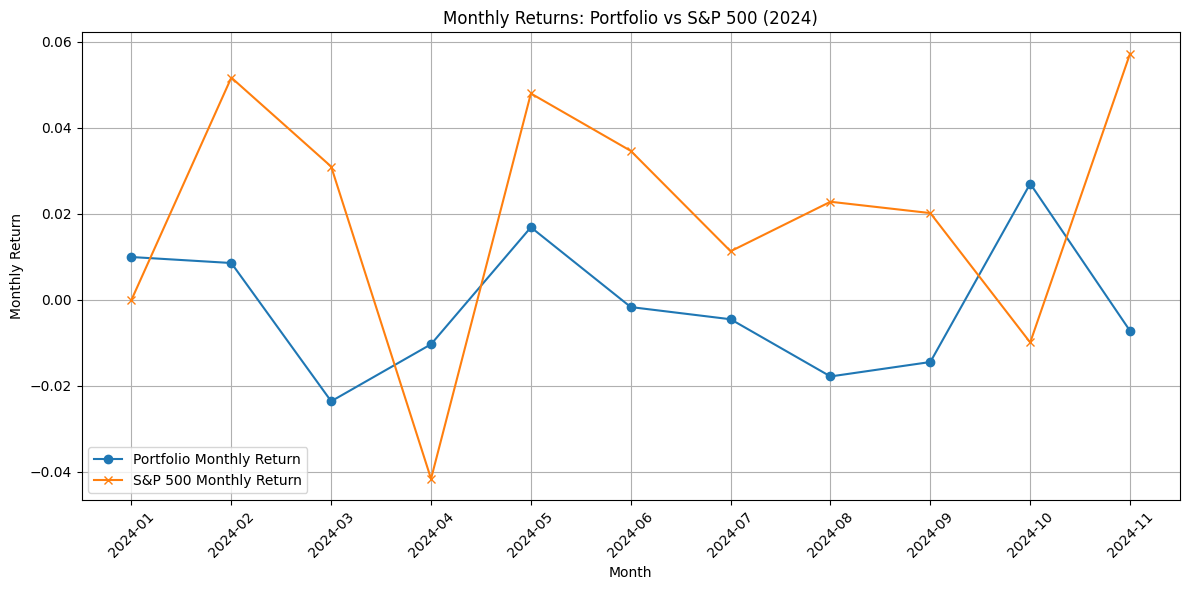

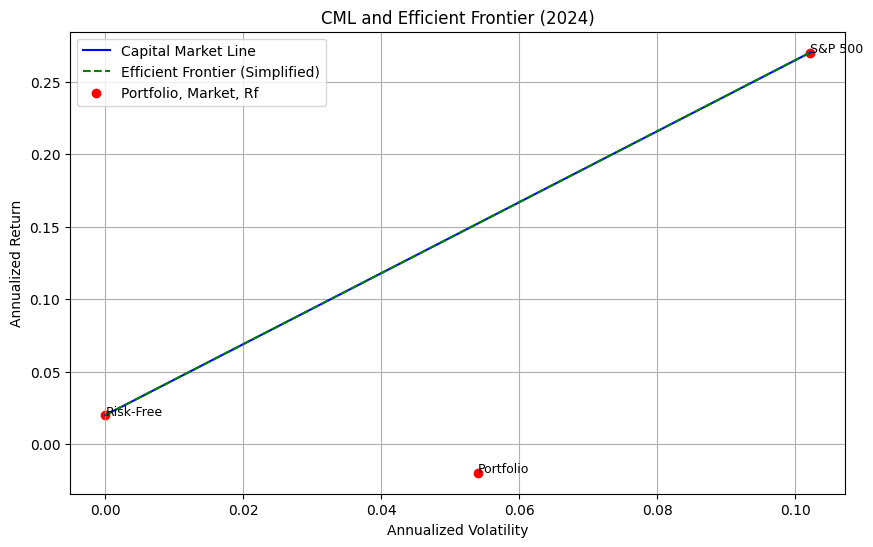

Performance evaluation complete.


In [45]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

# File paths
returns_path = 'portfolio_returns.csv'
portfolio_path = 'portfolio_selections.csv'
performance_path = 'portfolio_performance.csv'
sp500_index_path = 'sp500_index.csv'

# Date ranges (for test period)
test_start = '2024-01-01'
test_end = '2024-12-31'

# Fetch S&P 500 index data for 2024
def fetch_sp500_index():
    print("Fetching fresh S&P 500 index data for 2024...")
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    sp500.to_csv(sp500_index_path)
    print(f"Saved S&P 500 index data to {sp500_index_path}")
    return sp500

# Step 10: Evaluate performance with additional metrics
def evaluate_performance(returns_df, portfolio_df, risk_free_rate=0.02):
    print("Evaluating portfolio performance...")

    # Ensure year_month is a period for sorting
    returns_df['year_month'] = pd.to_datetime(returns_df['year_month']).dt.to_period('M')
    returns_df = returns_df.sort_values('year_month')
    print(f"returns_df shape: {returns_df.shape}")

    # Monthly returns
    print("\nMonthly Returns:")
    print(returns_df[['year_month', 'portfolio_return']].to_string(index=False))

    # Stocks chosen for long and short (filter to 2024)
    portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
    portfolio_df['year_month'] = portfolio_df['date'].dt.to_period('M')
    portfolio_2024 = portfolio_df[portfolio_df['year_month'].astype(str).str.startswith('2024')]
    print("\nStocks Chosen for Long and Short (2024):")
    for period, group in portfolio_2024.groupby('year_month'):
        long_stocks = group[group['position'] == 'long']['ticker'].tolist()
        short_stocks = group[group['position'] == 'short']['ticker'].tolist()
        print(f"{period}: Long: {long_stocks}, Short: {short_stocks}")

    # Cumulative returns
    returns_df['cumulative_return'] = (1 + returns_df['portfolio_return']).cumprod() - 1

    # Portfolio metrics
    n_months = len(returns_df)
    total_return = returns_df['cumulative_return'].iloc[-1] if n_months > 0 else 0
    annualized_return = ((1 + total_return) ** (12 / n_months)) - 1 if n_months > 0 else 0
    monthly_volatility = returns_df['portfolio_return'].std()
    annualized_volatility = monthly_volatility * np.sqrt(12) if pd.notna(monthly_volatility) else 0
    excess_return = annualized_return - risk_free_rate
    sharpe_ratio = excess_return / annualized_volatility if annualized_volatility != 0 else 0
    cumulative_series = (1 + returns_df['portfolio_return']).cumprod()
    rolling_max = cumulative_series.cummax()
    drawdowns = (cumulative_series - rolling_max) / rolling_max
    max_drawdown = drawdowns.min() if not drawdowns.empty else 0

    # Fetch and align S&P 500 data
    sp500 = fetch_sp500_index()
    sp500_monthly = sp500.resample('M').last().pct_change().dropna()
    sp500_monthly.index = sp500_monthly.index.to_period('M')
    print(f"sp500_monthly shape: {sp500_monthly.shape}, index: {sp500_monthly.index}")

    sp500_aligned = sp500_monthly.reindex(returns_df['year_month'], fill_value=0)
    print(f"sp500_aligned shape: {sp500_aligned.shape}, index: {sp500_aligned.index}")

    # Convert the one-column DataFrame to a Series for scalar operations
    sp500_total_return = (1 + sp500_aligned.iloc[:, 0]).cumprod().iloc[-1] - 1 if not sp500_aligned.empty else 0
    sp500_annualized_return = ((1 + sp500_total_return) ** (12 / len(sp500_aligned))) - 1 if len(sp500_aligned) > 0 else 0
    sp500_annualized_volatility = sp500_aligned.iloc[:, 0].std() * np.sqrt(12) if not sp500_aligned.empty else 0

    print(f"S&P 500 Metrics: total_return={sp500_total_return:.4f}, annualized_return={sp500_annualized_return:.4f}, annualized_volatility={sp500_annualized_volatility:.4f}")

    # CML and Efficient Frontier
    market_return = sp500_annualized_return
    market_volatility = sp500_annualized_volatility
    cml_slope = (market_return - risk_free_rate) / market_volatility if market_volatility != 0 else 0
    max_vol = max(annualized_volatility, market_volatility) if annualized_volatility is not np.nan and market_volatility is not np.nan else 0
    cml_volatilities = np.linspace(0, max_vol, 100)
    cml_returns = [risk_free_rate + cml_slope * vol for vol in cml_volatilities]

    portfolio_points = [(annualized_volatility, annualized_return)]
    market_points = [(market_volatility, market_return)]
    rf_points = [(0, risk_free_rate)]
    all_points = portfolio_points + market_points + rf_points
    vols, rets = zip(*all_points)
    efficient_vols = np.linspace(0, max(vols), 100)
    efficient_rets = [risk_free_rate + (market_return - risk_free_rate) * (v / market_volatility) if market_volatility != 0 else risk_free_rate for v in efficient_vols]

    # Compile performance metrics
    performance_metrics = {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown,
        'S&P 500 Annualized Return': sp500_annualized_return,
        'S&P 500 Annualized Volatility': sp500_annualized_volatility
    }

    # Save performance metrics
    performance_df = pd.DataFrame([performance_metrics])
    performance_df.to_csv(performance_path, index=False)
    print(f"Saved performance metrics to {performance_path}")

    # Print summary, ensuring each metric is a scalar before formatting
    print("\nPortfolio Performance Summary:")
    for key, value in performance_metrics.items():
        if isinstance(value, (pd.Series, np.ndarray)):
            value = value.item() if hasattr(value, 'item') else value[0]
        print(f"{key}: {value:.4f}")

    # Plotting
    plot_performance(returns_df, sp500_aligned.iloc[:, 0], cml_volatilities, cml_returns, efficient_vols, efficient_rets, vols, rets)

    return returns_df, performance_metrics

# Plotting function
def plot_performance(returns_df, sp500_returns, cml_vols, cml_rets, eff_vols, eff_rets, all_vols, all_rets):
    # Plot 1: Monthly Returns vs S&P 500
    plt.figure(figsize=(12, 6))
    plt.plot(returns_df['year_month'].astype(str), returns_df['portfolio_return'], label='Portfolio Monthly Return', marker='o')
    plt.plot(returns_df['year_month'].astype(str), sp500_returns, label='S&P 500 Monthly Return', marker='x')
    plt.title('Monthly Returns: Portfolio vs S&P 500 (2024)')
    plt.xlabel('Month')
    plt.ylabel('Monthly Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Plot 2: CML and Efficient Frontier
    plt.figure(figsize=(10, 6))
    plt.plot(cml_vols, cml_rets, label='Capital Market Line', color='blue')
    plt.plot(eff_vols, eff_rets, label='Efficient Frontier (Simplified)', color='green', linestyle='--')
    plt.scatter(all_vols, all_rets, c='red', label='Portfolio, Market, Rf')
    plt.text(0, 0.02, 'Risk-Free', fontsize=9)
    plt.text(all_vols[0], all_rets[0], 'Portfolio', fontsize=9)
    plt.text(all_vols[1], all_rets[1], 'S&P 500', fontsize=9)
    plt.title('CML and Efficient Frontier (2024)')
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Return')
    plt.legend()
    plt.grid()
    plt.show()

# Main execution
if __name__ == "__main__":
    returns_df = pd.read_csv(returns_path)
    portfolio_df = pd.read_csv(portfolio_path)
    returns_df, performance_metrics = evaluate_performance(returns_df, portfolio_df)
    print("Performance evaluation complete.")
